In [9]:
import os
import numpy as np
import pandas as pd
import yfinance as yf

import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import plotly.graph_objects as go


In [10]:
def load_data(symbol, start="2015-01-01", end=None):
    df = yf.download(symbol, start=start, end=end)

    # FULL FIX: Flatten ALL MultiIndex columns
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]

    # Now the columns are normal: Open, High, Low, Close, etc.
    df = df[["Close"]]
    df = df.rename(columns={"Close": "close_price"})
    df = df.dropna()

    df.index = pd.to_datetime(df.index)

    return df


In [11]:
def create_sequences(data, seq_len=60):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i])
    return np.array(X), np.array(y)


In [12]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)
        out = out[:, -1, :]
        return self.fc(out)



In [13]:
def train_stock(symbol):
    df = load_data(symbol)
    prices = df["close_price"].values.reshape(-1, 1)

    # scale
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(prices)

    # sequences
    X, y = create_sequences(scaled)
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    # reshape for PyTorch
    y = y.reshape(-1, 1)

    model = LSTMModel()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    epochs = 20
    batch_size = 32

    history = []

    for epoch in range(epochs):
        permutation = torch.randperm(X.size(0))
        epoch_loss = 0

        for i in range(0, X.size(0), batch_size):
            idx = permutation[i:i+batch_size]
            batch_x = X[idx]
            batch_y = y[idx]

            optimizer.zero_grad()
            output = model(batch_x)
            loss = loss_fn(output, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / (X.size(0) / batch_size)
        history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

    # SAVE MODEL (FIX)
    os.makedirs("models", exist_ok=True)

    torch.save({
        "model_state": model.state_dict(),
        "scaler": scaler
    }, f"models/{symbol}_model.pt")

    # next day prediction
    last_seq = torch.tensor(scaled[-60:], dtype=torch.float32).unsqueeze(0)
    pred_scaled = model(last_seq).detach().numpy()
    prediction = scaler.inverse_transform(pred_scaled)[0][0]

    return df, history, prediction


In [14]:
def plot_loss(history, symbol):
    plt.figure(figsize=(8, 4))
    plt.plot(history, label="Training Loss", color="blue")
    plt.title(f"{symbol} - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.show()



In [15]:
def plot_prediction(df, prediction, symbol):
    df_last = df.tail(400).copy()

    df_last["SMA_20"] = df_last["close_price"].rolling(20).mean()
    df_last["EMA_20"] = df_last["close_price"].ewm(span=20, adjust=False).mean()

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=df_last.index,
        y=df_last["close_price"],
        mode="lines",
        name="Actual Price",
        line=dict(color="blue")
    ))

    fig.add_trace(go.Scatter(
        x=df_last.index,
        y=df_last["SMA_20"],
        mode="lines",
        name="SMA 20",
        line=dict(color="orange")
    ))

    fig.add_trace(go.Scatter(
        x=df_last.index,
        y=df_last["EMA_20"],
        mode="lines",
        name="EMA 20",
        line=dict(color="green")
    ))

    fig.add_trace(go.Scatter(
        x=[df_last.index[-1] + pd.Timedelta(days=1)],
        y=[prediction],
        mode="markers",
        marker=dict(size=10, color="red"),
        name="Next-Day Prediction"
    ))

    fig.update_layout(
        title=f"{symbol} Forecast with SMA & EMA (Last 400 Days)",
        xaxis_title="Date",
        yaxis_title="Price"
    )

    fig.show()


/tmp/ipython-input-2749140290.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Epoch 1/20 - Loss: 0.040840
Epoch 2/20 - Loss: 0.000599
Epoch 3/20 - Loss: 0.000444
Epoch 4/20 - Loss: 0.000420
Epoch 5/20 - Loss: 0.000407
Epoch 6/20 - Loss: 0.000350
Epoch 7/20 - Loss: 0.000368
Epoch 8/20 - Loss: 0.000356
Epoch 9/20 - Loss: 0.000423
Epoch 10/20 - Loss: 0.000332
Epoch 11/20 - Loss: 0.000283
Epoch 12/20 - Loss: 0.000292
Epoch 13/20 - Loss: 0.000288
Epoch 14/20 - Loss: 0.000298
Epoch 15/20 - Loss: 0.000270
Epoch 16/20 - Loss: 0.000275
Epoch 17/20 - Loss: 0.000279
Epoch 18/20 - Loss: 0.000329
Epoch 19/20 - Loss: 0.000248
Epoch 20/20 - Loss: 0.000280


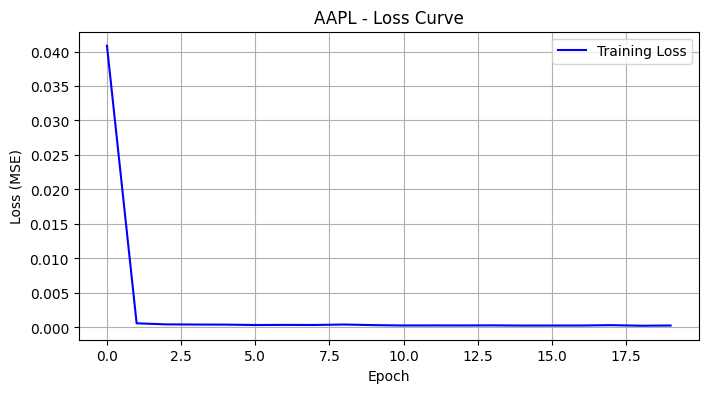

/tmp/ipython-input-2749140290.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Epoch 1/20 - Loss: 0.029150
Epoch 2/20 - Loss: 0.000311
Epoch 3/20 - Loss: 0.000275
Epoch 4/20 - Loss: 0.000274
Epoch 5/20 - Loss: 0.000232
Epoch 6/20 - Loss: 0.000296
Epoch 7/20 - Loss: 0.000247
Epoch 8/20 - Loss: 0.000238
Epoch 9/20 - Loss: 0.000222
Epoch 10/20 - Loss: 0.000246
Epoch 11/20 - Loss: 0.000242
Epoch 12/20 - Loss: 0.000234
Epoch 13/20 - Loss: 0.000224
Epoch 14/20 - Loss: 0.000178
Epoch 15/20 - Loss: 0.000201
Epoch 16/20 - Loss: 0.000190
Epoch 17/20 - Loss: 0.000184
Epoch 18/20 - Loss: 0.000214
Epoch 19/20 - Loss: 0.000162
Epoch 20/20 - Loss: 0.000218


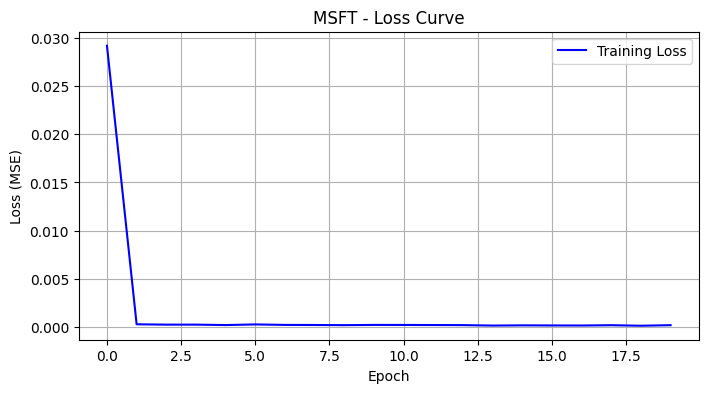

/tmp/ipython-input-2749140290.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Epoch 1/20 - Loss: 0.028482
Epoch 2/20 - Loss: 0.001181
Epoch 3/20 - Loss: 0.001009
Epoch 4/20 - Loss: 0.001002
Epoch 5/20 - Loss: 0.000831
Epoch 6/20 - Loss: 0.000709
Epoch 7/20 - Loss: 0.000675
Epoch 8/20 - Loss: 0.000716
Epoch 9/20 - Loss: 0.000588
Epoch 10/20 - Loss: 0.000557
Epoch 11/20 - Loss: 0.000532
Epoch 12/20 - Loss: 0.000500
Epoch 13/20 - Loss: 0.000557
Epoch 14/20 - Loss: 0.000497
Epoch 15/20 - Loss: 0.000508
Epoch 16/20 - Loss: 0.000443
Epoch 17/20 - Loss: 0.000439
Epoch 18/20 - Loss: 0.000484
Epoch 19/20 - Loss: 0.000435
Epoch 20/20 - Loss: 0.000433


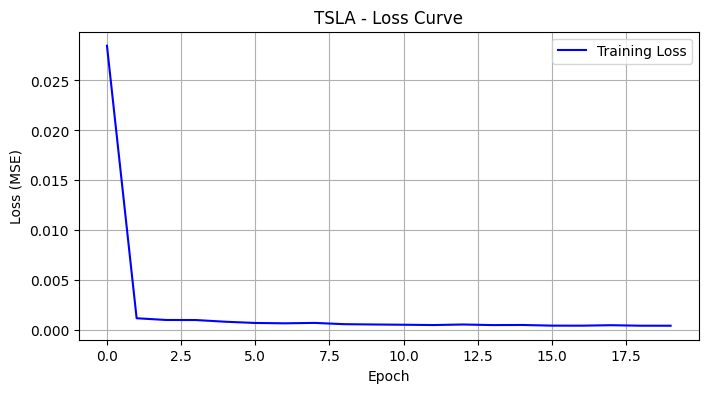

/tmp/ipython-input-2749140290.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Epoch 1/20 - Loss: 0.030350
Epoch 2/20 - Loss: 0.000758
Epoch 3/20 - Loss: 0.000739
Epoch 4/20 - Loss: 0.000609
Epoch 5/20 - Loss: 0.000512
Epoch 6/20 - Loss: 0.000573
Epoch 7/20 - Loss: 0.000474
Epoch 8/20 - Loss: 0.000434
Epoch 9/20 - Loss: 0.000425
Epoch 10/20 - Loss: 0.000465
Epoch 11/20 - Loss: 0.000372
Epoch 12/20 - Loss: 0.000395
Epoch 13/20 - Loss: 0.000420
Epoch 14/20 - Loss: 0.000337
Epoch 15/20 - Loss: 0.000309
Epoch 16/20 - Loss: 0.000346
Epoch 17/20 - Loss: 0.000319
Epoch 18/20 - Loss: 0.000275
Epoch 19/20 - Loss: 0.000324
Epoch 20/20 - Loss: 0.000272


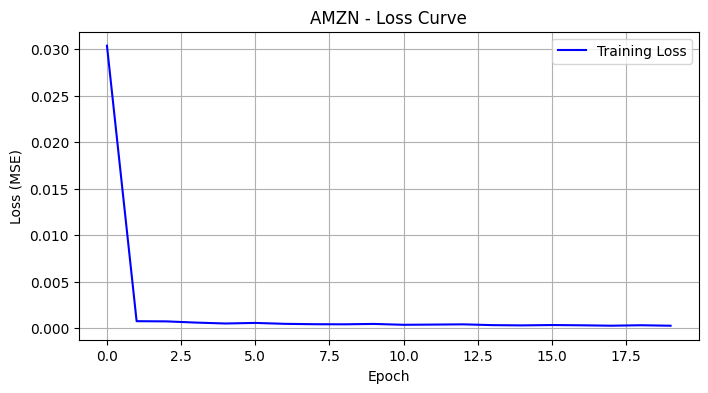

In [16]:
symbols = ["AAPL", "MSFT", "TSLA", "AMZN"]

results = {}

for sym in symbols:
    df, history, pred = train_stock(sym)
    results[sym] = pred
    plot_loss(history, sym)
    plot_prediction(df, pred, sym)

